# Advertising Sales Prediction

In this project, we will analyze how TV, Radio, and Newspaper advertising affect sales. We will also build a Linear Regression model to predict sales for a given advertising budget.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the Dataset

First, we load the advertising dataset and check the available data.

In [21]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [22]:
df.shape

(200, 4)

In [23]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [25]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [26]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Dataset Overview

The dataset contains four columns:

- TV: Advertising spend on television
- Radio: Advertising spend on radio
- Newspaper: Advertising spend on newspaper
- Sales: Product sales

## Select Features and Target

We will use TV, Radio, and Newspaper advertising spend to predict Sales.

In [27]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

## Split the Data

We divide the historical data into training data and testing data. The model will learn from the training data and be tested on unseen data.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build the Linear Regression Model

Linear Regression will learn the relationship between advertising spending and sales.

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.05,0.1 ,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.714
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


## Predict Sales for Unseen Data

Now we use the trained model to predict sales for the test data that the model has not seen before.

In [30]:
y_pred = model.predict(X_test)

In [31]:
results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

results.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


## Model Evaluation

We use MAE, MSE, RMSE, and R² score to understand how well the model performs.

In [32]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Squared Error: 2.907756910271091
Root Mean Squared Error: 1.7052146229349228
Mean Absolute Error: 1.274826210954934
R² Score: 0.9059011844150826


### Interpretation

The model has an R² score of about 0.91, which means it explains most of the variation in sales.

The Mean Absolute Error is about 1.27, so the model's predictions are typically off by around 1.27 sales units.

## Model Coefficients

The coefficients show how each advertising channel affects predicted sales when the other variables are kept constant.

In [33]:
print("Intercept:", model.intercept_)
print("TV Coefficient:", model.coef_[0])
print("Radio Coefficient:", model.coef_[1])
print("Newspaper Coefficient:", model.coef_[2])

Intercept: 4.714126402214134
TV Coefficient: 0.05450927083721976
Radio Coefficient: 0.10094536239295569
Newspaper Coefficient: 0.004336646822034035


In [34]:
print(
    f"Sales = {model.intercept_:.4f} + "
    f"{model.coef_[0]:.4f}*TV + "
    f"{model.coef_[1]:.4f}*Radio + "
    f"{model.coef_[2]:.4f}*Newspaper"
)

Sales = 4.7141 + 0.0545*TV + 0.1009*Radio + 0.0043*Newspaper


## Coefficient Interpretation

Radio has the strongest impact based on the regression coefficients because it has the highest coefficient.

TV also has a positive effect on sales.

Newspaper has the smallest coefficient, so it has the least impact on sales in this model.

All three coefficients are positive, which means higher advertising spending is associated with higher predicted sales.

## Predict Sales for a New Advertising Budget

Now we will predict sales for the planned advertising budget given in the assignment.

In [35]:
new_budget = pd.DataFrame({
    'TV': [150],
    'Radio': [20],
    'Newspaper': [30]
})

predicted_sales = model.predict(new_budget)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 15.039523680317231


### Prediction

For a budget of TV = 150, Radio = 20, and Newspaper = 30, the model predicts approximately 15.04 sales units.

## Actual Sales vs Predicted Sales

This graph compares the actual sales values with the values predicted by the model.

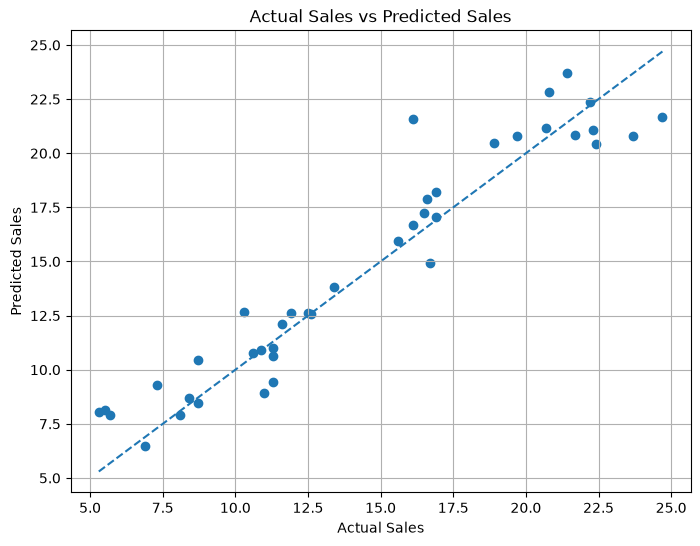

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")
plt.grid(True)
plt.show()

## Advertising Impact

The following chart shows the coefficients of the three advertising channels.

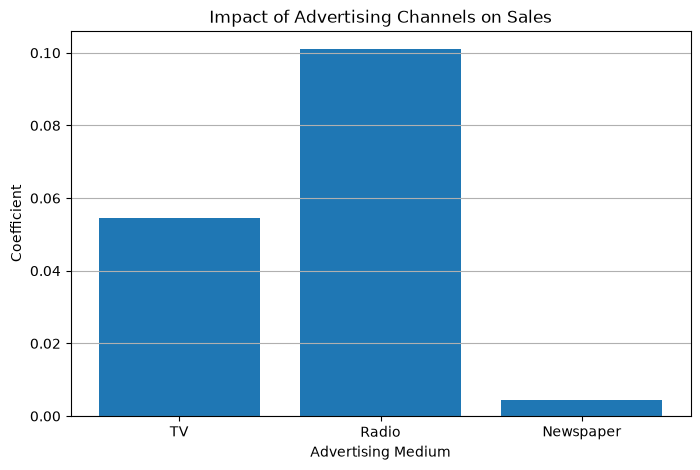

In [37]:
features = ['TV', 'Radio', 'Newspaper']
coefficients = model.coef_

plt.figure(figsize=(8, 5))
plt.bar(features, coefficients)
plt.xlabel("Advertising Medium")
plt.ylabel("Coefficient")
plt.title("Impact of Advertising Channels on Sales")
plt.grid(axis='y')
plt.show()

## Business Recommendation

Based on the model, the company should give more attention to Radio advertising because it has the strongest regression coefficient. The company can increase or optimize its Radio advertising budget and track whether sales improve.

## Technical Improvement

Prediction accuracy can be improved by testing other machine learning models such as Random Forest or Gradient Boosting and comparing their results with Linear Regression. Hyperparameter tuning and cross-validation can also help select a better model.

## Conclusion

The analysis shows that TV, Radio, and Newspaper advertising all have a positive relationship with sales. A Linear Regression model was trained using historical data and achieved an R² score of about 0.91.

Radio has the strongest impact based on the model coefficients, while Newspaper has the least impact.

For the advertising budget of TV = 150, Radio = 20, and Newspaper = 30, the predicted sales are approximately 15.04 units.

The model gives reasonably accurate predictions, but other machine learning models can be tested to improve accuracy further.